### Домашнє завдання: Кластеризація в Аналізі Персоналій Клієнтів

#### Контекст
В цьому ДЗ ми скористаємось алгоритмами кластеризації для задачі аналізу портретів клієнтів (Customer Personality Analysis).

Customer Personality Analysis - це аналіз різних сегментів клієнтів компанії. Цей аналіз дозволяє бізнесу краще розуміти своїх клієнтів і полегшує процес адаптації продуктів під конкретні потреби, поведінку та інтереси різних типів клієнтів.

Аналіз портретів клієнтів допомагає бізнесу змінювати свій продукт на основі цільової аудиторії, розділеної на різні сегменти. Наприклад, замість того, щоб витрачати гроші на маркетинг нового продукту для всіх клієнтів у базі даних компанії, бізнес може проаналізувати, який сегмент клієнтів найімовірніше придбає продукт, і потім зосередити маркетингові зусилля лише на цьому сегменті.

#### Завдання
На основі наданих даних в файлі `marketing_campaign.csv` потрібно виконати кластеризацію, щоб виявити сегменти клієнтів.

#### Вхідні дані
Вам надано набір даних з такими атрибутами:

**Характеристики користувачів:**
- `ID`: Унікальний ідентифікатор клієнта
- `Year_Birth`: Рік народження клієнта
- `Education`: Рівень освіти клієнта
- `Marital_Status`: Сімейний стан клієнта
- `Income`: Річний дохід домогосподарства клієнта
- `Kidhome`: Кількість дітей у домогосподарстві клієнта
- `Teenhome`: Кількість підлітків у домогосподарстві клієнта
- `Dt_Customer`: Дата реєстрації клієнта у компанії
- `Recency`: Кількість днів з моменту останньої покупки клієнта
- `Complain`: 1, якщо клієнт скаржився за останні 2 роки, 0 - якщо ні

**Продукти:**
- `MntWines`: Сума, витрачена на вино за останні 2 роки
- `MntFruits`: Сума, витрачена на фрукти за останні 2 роки
- `MntMeatProducts`: Сума, витрачена на м'ясні продукти за останні 2 роки
- `MntFishProducts`: Сума, витрачена на рибні продукти за останні 2 роки
- `MntSweetProducts`: Сума, витрачена на солодощі за останні 2 роки
- `MntGoldProds`: Сума, витрачена на золото за останні 2 роки

**Акції:**
- `NumDealsPurchases`: Кількість покупок, зроблених з використанням знижок
- `AcceptedCmp1`: 1, якщо клієнт прийняв пропозицію у першій кампанії, 0 - якщо ні
- `AcceptedCmp2`: 1, якщо клієнт прийняв пропозицію у другій кампанії, 0 - якщо ні
- `AcceptedCmp3`: 1, якщо клієнт прийняв пропозицію у третій кампанії, 0 - якщо ні
- `AcceptedCmp4`: 1, якщо клієнт прийняв пропозицію у четвертій кампанії, 0 - якщо ні
- `AcceptedCmp5`: 1, якщо клієнт прийняв пропозицію у п'ятій кампанії, 0 - якщо ні
- `Response`: 1, якщо клієнт прийняв пропозицію в останній кампанії, 0 - якщо ні

**Взаємодія з компанією:**
- `NumWebPurchases`: Кількість покупок, зроблених через вебсайт компанії
- `NumCatalogPurchases`: Кількість покупок, зроблених за каталогом
- `NumStorePurchases`: Кількість покупок, зроблених безпосередньо у магазинах
- `NumWebVisitsMonth`: Кількість відвідувань вебсайту компанії за останній місяць


**Завдання 1**. Завантажте дані з `marketing_campaign.csv` в Pandas dataframe і виведіть основну інформацію про дані: скільки всього рядків і колонок, які типи даних мають колонки, скільки пропущених значень.

In [43]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn import metrics

In [44]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [45]:
df = pd.read_csv('drive/MyDrive/Colab Notebooks/marketing_campaign.csv', sep=None, engine="python")

In [46]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

In [47]:
empty_values = df.isnull().sum()
empty_values[empty_values>0]


,0
Income,24


In [48]:
df["Income"].value_counts()

,count
Income,
7500.0,12
35860.0,4
18929.0,3
46098.0,3
67445.0,3
...,...
5305.0,1
80617.0,1
38054.0,1


**Завдання 2.** Заповніть пропущені значення з врахуванням того завдання (кластеризація), яке ми виконуємо. Поясніть свій вибір заповнення пропущених значень.

Колонка Income це Річний дохід домогосподарства клієнта, а отже на мою думку є важливою, тому я заповню пропущені значення медіаною і додам ще одну колонку де вкажу - тут було пропущене значення а тут ні. Таким чином зберігається інформація про дохід та його відсутність.

In [49]:
df['Income_missing'] = df['Income'].isnull().astype(int)
df['Income'] = df['Income'].fillna(df['Income'].median())

**Завдання 3.** У нас є декілька колонок з категоріальними значеннями та одна колонка з датою. Як би ви обробили ці колонки для того, аби передати їх в алгоритм кластеризації?

Реалізуйте обробку категоріальних колонок і колонки з датою та перетворіть їх на ознаки, корисні для кластеризації з вашого погляду.

у нас 3 категоріальні колонки Education, Marital_Status, Dt_Customer. Остання з них це дата але не в числовому форматі. Ми переведемо в числовий формат а потім порахуємо скільки днів клієнт з нами згідно цієї дати та замінимо існуючу дату на нове значення.

In [50]:
df[["Education","Marital_Status","Dt_Customer"]].value_counts()

Education   Marital_Status  Dt_Customer
Graduation  Married         16-02-2013     5
PhD         Married         23-11-2012     5
Graduation  Married         14-02-2013     5
            Single          19-07-2013     5
            Together        31-08-2012     5
                                          ..
            Single          06-05-2013     1
                            06-04-2013     1
                            06-03-2014     1
                            06-01-2014     1
                            08-05-2014     1
Name: count, Length: 1778, dtype: int64

In [51]:
categorical_cols = ["Education", "Marital_Status"]

In [52]:
#перетворимо дані колонки в числовий формат та замінюємо на колонку, яка показує, як довго з нами клієнт
df['Dt_Customer'] = pd.to_datetime(df['Dt_Customer'], dayfirst=True, errors='coerce')
min_date = df['Dt_Customer'].min()
df['Days_Since_Customer'] = (df['Dt_Customer'] - min_date).dt.days
df = df.drop(columns=['Dt_Customer'])


In [53]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(drop="first", sparse_output=False)
encoded_array = encoder.fit_transform(df[categorical_cols])

encoded_columns = pd.DataFrame(
    encoded_array,
    columns=encoder.get_feature_names_out(categorical_cols),
    index=df.index
)

In [54]:
df_encoded = pd.concat([df.drop(columns=categorical_cols), encoded_columns], axis=1)

In [55]:
df_encoded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 39 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   ID                       2240 non-null   int64  
 1   Year_Birth               2240 non-null   int64  
 2   Income                   2240 non-null   float64
 3   Kidhome                  2240 non-null   int64  
 4   Teenhome                 2240 non-null   int64  
 5   Recency                  2240 non-null   int64  
 6   MntWines                 2240 non-null   int64  
 7   MntFruits                2240 non-null   int64  
 8   MntMeatProducts          2240 non-null   int64  
 9   MntFishProducts          2240 non-null   int64  
 10  MntSweetProducts         2240 non-null   int64  
 11  MntGoldProds             2240 non-null   int64  
 12  NumDealsPurchases        2240 non-null   int64  
 13  NumWebPurchases          2240 non-null   int64  
 14  NumCatalogPurchases     

In [56]:
from sklearn.preprocessing import StandardScaler
scale_cols = [
    "Year_Birth","Income","Recency",
    "MntWines","MntFruits","MntMeatProducts","MntFishProducts",
    "MntSweetProducts","MntGoldProds",
    "NumDealsPurchases","NumWebPurchases","NumCatalogPurchases",
    "NumStorePurchases","NumWebVisitsMonth",
    "Days_Since_Customer"
]

scaler = StandardScaler()
df_encoded[scale_cols] = scaler.fit_transform(df_encoded[scale_cols])

In [58]:
df_encoded[:10]

,ID,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,...,Education_Graduation,Education_Master,Education_PhD,Marital_Status_Alone,Marital_Status_Divorced,Marital_Status_Married,Marital_Status_Single,Marital_Status_Together,Marital_Status_Widow,Marital_Status_YOLO
0,5524,-0.985345,0.235696,0,0,0.307039,0.983781,1.551577,1.679702,2.462147,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1,2174,-1.235733,-0.235454,1,1,-0.383664,-0.870479,-0.636301,-0.713225,-0.650449,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,4141,-0.317643,0.773999,0,0,-0.798086,0.362723,0.570804,-0.177032,1.345274,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3,6182,1.268149,-1.022355,1,0,-0.798086,-0.870479,-0.560857,-0.651187,-0.503974,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,5324,1.017761,0.241888,1,0,1.550305,-0.389085,0.419916,-0.216914,0.155164,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
5,7446,-0.150717,0.410470,0,1,-1.143438,0.642051,0.394768,-0.305541,-0.687068,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
6,965,0.183134,0.135705,0,1,-0.521805,-0.204847,0.973172,-0.013072,0.228401,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
7,6177,1.351612,-0.750388,1,0,-0.590875,-0.677327,-0.409969,-0.491658,-0.632140,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
8,4855,0.433522,-0.874347,1,0,-1.039832,-0.861565,-0.661449,-0.633461,-0.632140,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
9,5899,-1.569584,-1.861189,1,1,0.652391,-0.819963,-0.661449,-0.713225,-0.668759,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


**Завдання 4**.
1. Запишіть в змінну X ті дані, які будете кластеризувати.
2. Побудуйте кластеризацію з KMeans на 3 кластери.
3. Обчисліть метрику силуету для цієї кластеризації.

In [59]:
X = df_encoded.drop(columns=['ID'])

from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42)
labels = kmeans.fit_predict(X)

df_encoded['Cluster'] = labels

from sklearn.metrics import silhouette_score

silhouette = silhouette_score(X, labels)
print(f"Silhouette Score: {silhouette:.4f}")

Silhouette Score: 0.1887


**Завдання 6**. Масштабуйте дані (StandardScaler/MinMaxScaler) і побудуйте знову кластеризацію KMeans на 3 кластери і обчисліть метрику силуету. Опишіть порівняння з експериментом без масштабування значень.

In [60]:
import plotly.express as px

fig = px.scatter_3d(
    df_encoded,
    x="Income",
    y="NumWebPurchases",
    z="Recency",
    color="Cluster",
    symbol="Cluster",
    opacity=0.7,
    title="3D візуалізація кластерів"
)
fig.show()

Silhouette Score = 0.1887 показав, що кластери не дуже чітко відокремлені. Це видно і на графіку: групи частково перекриваються.
Проте навіть при такому результаті можна виділити сегменти за доходом і активністю.

**Завдання 5.** Візуалізуйте знайдені кластери разом з наявними даними та проаналізуйте кластери. У нас ознак більше, ніж 2 або 3, тож, тут треба подумати, які саме ознаки варто використати для візуалізації аби вони були інформативними. Рекомендую точно звернути увагу на харакетиристики про дохід користувачів і те, як вони взаємодять з магазинок (кількість покупок і тд).

Для візуалізації зручно може бути використати `plotly.express.scatter_3d` для 3D графіку розсіювання, але тут можна скористатись будь-яким зрозумілим і зручним для вас методом візуалізації. Опишіть свої спостереження, чи кластери мають сенс?

In [61]:
df_original = df_encoded.copy()
df_original[scale_cols] = scaler.inverse_transform(df_encoded[scale_cols])


In [62]:
df_original[:5]

,ID,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,...,Education_Master,Education_PhD,Marital_Status_Alone,Marital_Status_Divorced,Marital_Status_Married,Marital_Status_Single,Marital_Status_Together,Marital_Status_Widow,Marital_Status_YOLO,Cluster
0,5524,1957.0,58138.0,0,0,58.0,635.0,88.0,546.0,172.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1
1,2174,1954.0,46344.0,1,1,38.0,11.0,1.0,6.0,2.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,2
2,4141,1965.0,71613.0,0,0,26.0,426.0,49.0,127.0,111.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1
3,6182,1984.0,26646.0,1,0,26.0,11.0,4.0,20.0,10.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,2
4,5324,1981.0,58293.0,1,0,94.0,173.0,43.0,118.0,46.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0


In [65]:
X_ = df_original.drop(columns=['ID'])

kmeans_ = KMeans(n_clusters=3, random_state=42)
labels_ = kmeans_.fit_predict(X_)

df_original['Cluster'] = labels_

silhouette_ = silhouette_score(X_, labels_)
print(f"Silhouette Score без масштабування: {silhouette_:.4f}")


Silhouette Score без масштабування: 0.5379


In [66]:
fig = px.scatter_3d(
    df_original,
    x="Income",
    y="NumWebPurchases",
    z="Recency",
    color="Cluster",
    symbol="Cluster",
    opacity=0.7,
    title="3D візуалізація кластерів"
)
fig.show()

силует без масштабування вийшов вищим (≈0.54 проти ~0.18). Це означає, що для наших даних масштабування не допомогло, а навіть погіршило структуру кластерів. Ну і загалом можна зробити висновок, що розбиття на 3 кластери не дуже добре спрацювало.


**Завдання 7.** З візуалізацій на попередньому кроці ви могли побачити якісь викиди в даних. Опрацюйте викиди (можна видалити ці рядки або придумати інший спосіб).

In [67]:
def remove_outliers_iqr(df, cols):
    df_clean = df.copy()
    for col in cols:
        Q1 = df_clean[col].quantile(0.25)
        Q3 = df_clean[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        df_clean = df_clean[(df_clean[col] >= lower) & (df_clean[col] <= upper)]
    return df_clean

outlier_cols = ["Income", "Recency", "NumWebPurchases"]
df_no_outliers = remove_outliers_iqr(df_encoded, outlier_cols)

print("Було рядків:", len(df_encoded))
print("Залишилось після видалення:", len(df_no_outliers))


Було рядків: 2240
Залишилось після видалення: 2228


In [69]:
X_no_outliers = df_no_outliers.drop(columns=['ID'])

kmeans_no = KMeans(n_clusters=3, random_state=42)
labels_no = kmeans_no.fit_predict(X_no_outliers)

df_no_outliers['Cluster'] = labels_no

silhouette_no = silhouette_score(X_no_outliers, labels_no)
print(f"Silhouette Score без викидів: {silhouette_no:.4f}")

Silhouette Score без викидів: 0.2333


**Завдання 8.** Виконайте Elbow method для пошуку оптимальної кількості кластерів та натренуйте KMeans з тою кількістю кластерів, яку Elbow method показав як оптимальну. Обчисліть метрику силуету. Візуалізуйте кластери. З яким набором даних (масштабованим чи ні) тут працювати - ваш вибір, можна зробити експеримент з обома.

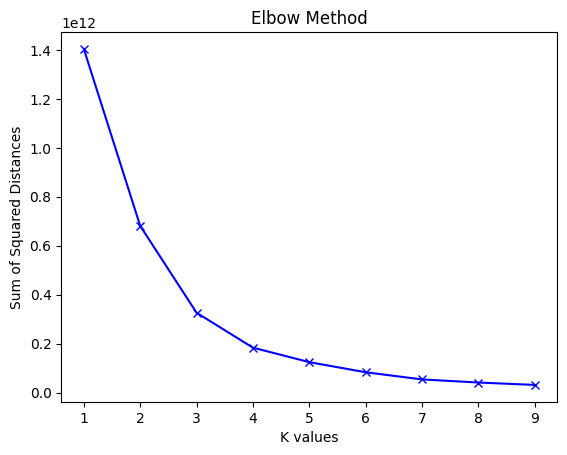

In [70]:
K = range(1,10)
sum_of_squared_distances = []

for k in K:
    model = KMeans(n_clusters=k, n_init='auto').fit(X_)
    sum_of_squared_distances.append(model.inertia_)

plt.plot(K, sum_of_squared_distances, 'bx-')
plt.xlabel('K values')
plt.ylabel('Sum of Squared Distances')
plt.title('Elbow Method')
plt.show()

In [81]:
kmeans_4 = KMeans(n_clusters=4, random_state=42)
labels_4 = kmeans_4.fit_predict(X_)

df_original['Cluster'] = labels_4

silhouette_4 = silhouette_score(X_, labels_4)
print(f"Silhouette Score без масштабування: {silhouette_4:.4f}")

Silhouette Score без масштабування: 0.5437


In [82]:
fig = px.scatter_3d(
    df_original,
    x="Income",
    y="NumWebPurchases",
    z="Recency",
    color="Cluster",
    symbol="Cluster",
    opacity=0.7,
    title="3D візуалізація кластерів"
)
fig.show()

**Завдання 9.** Використовуючи методи `scipy` `dendrogram, linkage, fcluster`
1. Побудуйте ієрархічну агломеративну кластеризацію з `single linkage` на даних невідмасштабованих, але з прибраним викидом.
2. Візуалізуйте дендрограму. При візуалізації обовʼязково задайте параметр `truncate_mode='lastp'` - це обріже дендрограму, без цього вона буде завелика, бо у нас тут даних суттєво більше, ніж в лекції.
3. Проаналізуйте дендрограму та побудуйте варіанти плоских кластеризацій з `fcluster` на 2 і 3 кластери. Візуалізуйте результати кожної з цих кластеризацій та зробіть висновок. Чи вважаєте ви якусь з цих кластеризацій вдалою? Що спостерігаєте з цих кластеризацій?
4. Порахуйте мерику силуету для цього методу кластеризації.

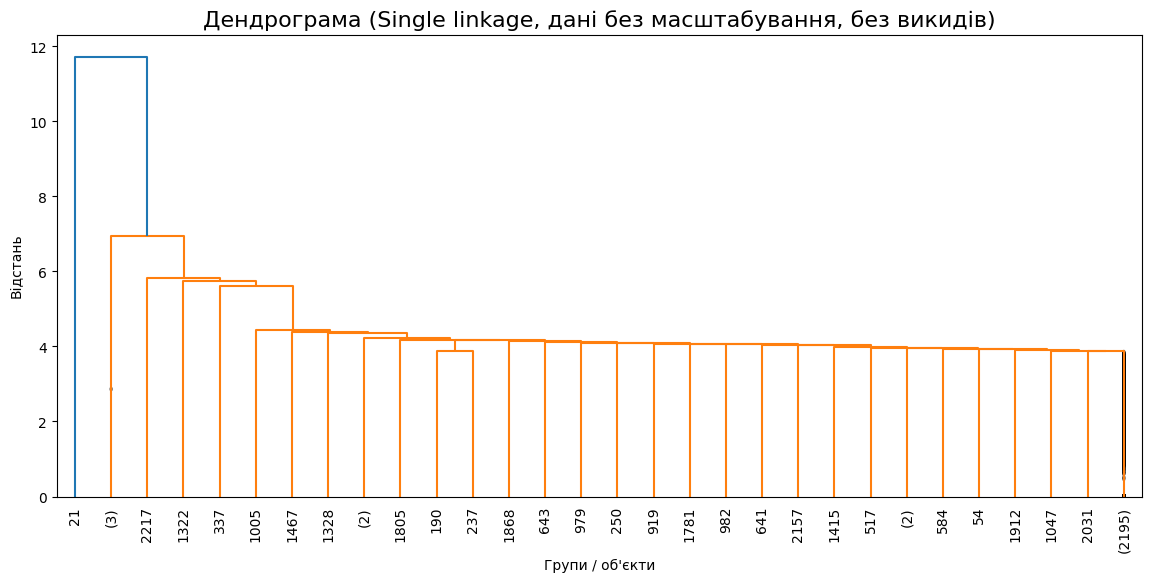

In [87]:
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt

linked = linkage(X_no_outliers, method='single')

plt.figure(figsize=(14, 6))
dendrogram(
    linked,
    truncate_mode='lastp',
    p=30,
    leaf_rotation=90,
    leaf_font_size=10,
    show_contracted=True
)
plt.xlabel("Групи / об'єкти")
plt.ylabel("Відстань")
plt.title("Дендрограма (Single linkage, дані без масштабування, без викидів)", fontsize=16)
plt.show()



In [89]:
# 2. Плоска кластеризація на 2 кластери
labels_2 = fcluster(linked, 2, criterion='maxclust')
df_no_outliers['Cluster_2'] = labels_2

# 3. Плоска кластеризація на 3 кластери
labels_3 = fcluster(linked, 3, criterion='maxclust')
df_no_outliers['Cluster_3'] = labels_3


In [90]:
fig2 = px.scatter_3d(
    df_no_outliers,
    x="Income",
    y="NumWebPurchases",
    z="Recency",
    color="Cluster_2",
    symbol="Cluster_2",
    opacity=0.7,
    title="3D візуалізація кластерів (2 кластери, single linkage)"
)
fig2.show()

fig3 = px.scatter_3d(
    df_no_outliers,
    x="Income",
    y="NumWebPurchases",
    z="Recency",
    color="Cluster_3",
    symbol="Cluster_3",
    opacity=0.7,
    title="3D візуалізація кластерів (3 кластери, single linkage)"
)
fig3.show()

Жодна з кластеризацій не виглядає вдалою. \
метод single linkage не підходить для цих даних: він створює ланцюжки і не формує компактних, щільних груп.
Отже: при 2 і 3 кластерах ми бачимо один великий кластер і кілька дрібних, що не дає інформативної сегментації.

**Завдання 10.**
1. Використайте метод кластеризації, який ми не використовували в попередніх завданнях цього ДЗ (може бути ієрархічна кластеризація з іншим способом звʼязності або інші методи sklearn).
2. Порахуйте мер=трику силуету і візуалізуйте результат кластеризації. Зробіть висновок про те, чи могла б ця кластеризація бути корисною?

In [91]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=500, min_samples=5)
labels_db = dbscan.fit_predict(X_no_outliers)

df_no_outliers['Cluster_DBSCAN'] = labels_db

# DBSCAN може мати -1 (шум), тому силует рахуємо тільки якщо є >1 кластер
if len(set(labels_db)) > 1:
    silhouette_db = silhouette_score(X_no_outliers, labels_db)
    print(f"Silhouette Score (DBSCAN): {silhouette_db:.4f}")
else:
    print("DBSCAN знайшов лише один кластер, силует не рахується.")

fig = px.scatter_3d(
    df_no_outliers,
    x="Income",
    y="NumWebPurchases",
    z="Recency",
    color="Cluster_DBSCAN",
    symbol="Cluster_DBSCAN",
    opacity=0.7,
    title="DBSCAN clustering"
)
fig.show()


DBSCAN знайшов лише один кластер, силует не рахується.


In [92]:
from sklearn.cluster import AgglomerativeClustering

# Кластеризація на 3 кластери методом Ward
agg = AgglomerativeClustering(n_clusters=3, linkage='ward')
labels_ward = agg.fit_predict(X_no_outliers)

# Додаємо мітки у датафрейм
df_no_outliers['Cluster_Ward'] = labels_ward

# Обчислюємо силует
silhouette_ward = silhouette_score(X_no_outliers, labels_ward)
print(f"Silhouette Score (Ward linkage, 3 кластери): {silhouette_ward:.4f}")

# Візуалізація
fig = px.scatter_3d(
    df_no_outliers,
    x="Income",
    y="NumWebPurchases",
    z="Recency",
    color="Cluster_Ward",
    symbol="Cluster_Ward",
    opacity=0.7,
    title="Agglomerative Clustering (Ward linkage, 3 кластери)"
)
fig.show()


Silhouette Score (Ward linkage, 3 кластери): 0.2251


DBSCAN: знайшов лише один кластер, метод не виявив щільних груп у даних. Для цієї задачі він не дав корисного результату.

Ward linkage (3 кластери): Silhouette Score ≈ 0.2251 це низьке значення, яке свідчить про слабку відокремленість кластерів. Кластери перекриваються, і структура даних не має чітких меж.

Низький силует показує, що клієнти більше схожі один на одного, ніж відрізняються за обраними ознаками.

У такому вигляді ця кластеризація не є особливо корисною для сегментації клієнтів.